# KNN 

## Librerías

In [1]:
import numpy as np
import pandas as pd
import glob
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

warnings.filterwarnings('ignore')


## 1. Data Loading

In [ ]:
import os
DATASETS = glob.glob(os.path.join("dataset", "*.csv"))
print(DATASETS) 


dfs = [pd.read_csv(path) for path in DATASETS]
df = pd.concat(dfs, ignore_index=True)

['C:\\Users\\victo\\Desktop\\dataset\\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'C:\\Users\\victo\\Desktop\\dataset\\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'C:\\Users\\victo\\Desktop\\dataset\\Friday-WorkingHours-Morning.pcap_ISCX.csv', 'C:\\Users\\victo\\Desktop\\dataset\\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'C:\\Users\\victo\\Desktop\\dataset\\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'C:\\Users\\victo\\Desktop\\dataset\\Tuesday-WorkingHours.pcap_ISCX.csv']


In [3]:
df.head()
df.shape
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1608122 entries, 0 to 1608121
Data columns (total 79 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0    Destination Port             1608122 non-null  int64  
 1    Flow Duration                1608122 non-null  int64  
 2    Total Fwd Packets            1608122 non-null  int64  
 3    Total Backward Packets       1608122 non-null  int64  
 4   Total Length of Fwd Packets   1608122 non-null  int64  
 5    Total Length of Bwd Packets  1608122 non-null  int64  
 6    Fwd Packet Length Max        1608122 non-null  int64  
 7    Fwd Packet Length Min        1608122 non-null  int64  
 8    Fwd Packet Length Mean       1608122 non-null  float64
 9    Fwd Packet Length Std        1608122 non-null  float64
 10  Bwd Packet Length Max         1608122 non-null  int64  
 11   Bwd Packet Length Min        1608122 non-null  int64  
 12   Bwd Packet Length Mean       1608122 n

## 2. Preprocessing

Checking for NaN / null values

In [4]:
df.isnull().sum()


 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
 Label                         0
Length: 79, dtype: int64

In [5]:
df.isnull().sum()[df.isnull().sum() > 0]


Flow Bytes/s    286
dtype: int64

In [6]:
# Drop rows with missing values
df = df.dropna()
df.isnull().sum() * 100 / df.shape[0]


 Destination Port              0.0
 Flow Duration                 0.0
 Total Fwd Packets             0.0
 Total Backward Packets        0.0
Total Length of Fwd Packets    0.0
                              ... 
Idle Mean                      0.0
 Idle Std                      0.0
 Idle Max                      0.0
 Idle Min                      0.0
 Label                         0.0
Length: 79, dtype: float64

Verifying no nulls remain:

In [7]:
df.isnull().sum()[df.isnull().sum() > 0]


Series([], dtype: int64)

Checking for non-numeric columns (dummies needed?):

In [8]:
df.select_dtypes(exclude=['number']).columns


Index([' Label'], dtype='str')

All columns are numeric : no dummy encoding required.

## 3. Normalisation

In [9]:
# Remove leading/trailing whitespace from column names
df.columns = df.columns.str.strip()

# Separate features and target
X = df.drop('Label', axis=1)
y = df['Label']

# Replace infinite values with NaN, then drop affected rows
X = X.replace([np.inf, -np.inf], np.nan)
mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]

# Normalise features to [0, 1] — required for distance-based models like KNN
scaler = preprocessing.MinMaxScaler()
X_norm = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
).reset_index(drop=True)
y = y.reset_index(drop=True)

X_norm.head()


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,0.837212,1.333333e-07,0.000005,0.000000,9.302326e-07,0.000000e+00,0.000242,0.002581,0.00101,0.0,...,0.000005,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.840096,1.016667e-06,0.000000,0.000004,4.651163e-07,9.569378e-09,0.000242,0.002581,0.00101,0.0,...,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.840111,5.416666e-07,0.000000,0.000004,4.651163e-07,9.569378e-09,0.000242,0.002581,0.00101,0.0,...,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.705538,3.916666e-07,0.000000,0.000004,4.651163e-07,9.569378e-09,0.000242,0.002581,0.00101,0.0,...,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.837181,1.333333e-07,0.000005,0.000000,9.302326e-07,0.000000e+00,0.000242,0.002581,0.00101,0.0,...,0.000005,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Training / Test Split

In [10]:
X = X_norm

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size   = 0.8,
    random_state = 1234,
    shuffle      = True,
    stratify     = y
)


## 5. Model

### k search

The full training set is too large for an exhaustive k search with KNN. A random subsample is used to find the best k efficiently.

In [11]:
train_sample_n = 20000
test_sample_n  = 5000

if len(X_train) > train_sample_n:
    X_train_s, _, y_train_s, _ = train_test_split(
        X_train, y_train,
        train_size=train_sample_n,
        stratify=y_train,
        random_state=42
    )
else:
    X_train_s, y_train_s = X_train, y_train

if len(X_test) > test_sample_n:
    X_test_s, _, y_test_s, _ = train_test_split(
        X_test, y_test,
        train_size=test_sample_n,
        stratify=y_test,
        random_state=42
    )
else:
    X_test_s, y_test_s = X_test, y_test

print('Subsample sizes:', X_train_s.shape, X_test_s.shape)


Subsample sizes: (20000, 78) (5000, 78)


#### Accuracy vs k

k= 2 acc=0.9740
k= 3 acc=0.9764
k= 4 acc=0.9744
k= 5 acc=0.9752
k= 6 acc=0.9746
k= 7 acc=0.9750
k= 9 acc=0.9760
k=11 acc=0.9748
k=13 acc=0.9744
k=14 acc=0.9748
k=15 acc=0.9746
k=16 acc=0.9752
k=17 acc=0.9746
k=18 acc=0.9752
k=20 acc=0.9752
k=21 acc=0.9756
k=22 acc=0.9756
k=23 acc=0.9748
k=24 acc=0.9748
k=25 acc=0.9746

Best k (accuracy): 3


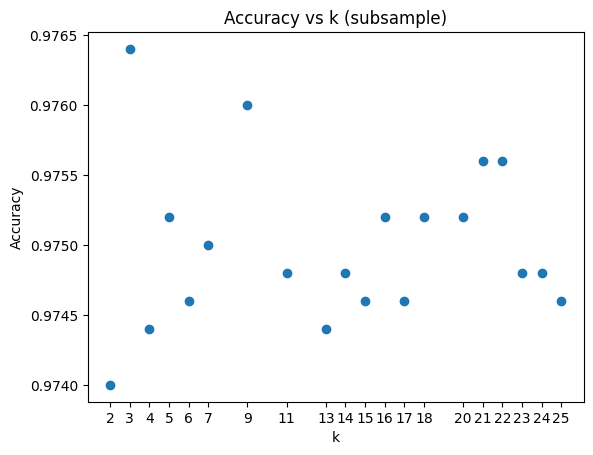

In [12]:
k_range = [2, 3, 4, 5, 6, 7, 9, 11, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24, 25]
scores = []

for k in k_range:
    model = make_pipeline(
        MinMaxScaler(),
        KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    )
    model.fit(X_train_s, y_train_s)
    pred = model.predict(X_test_s)
    acc = accuracy_score(y_test_s, pred)
    scores.append(acc)
    print(f'k={k:>2} acc={acc:.4f}')

best_k = k_range[int(np.argmax(scores))]
print('\nBest k (accuracy):', best_k)

plt.figure()
plt.title('Accuracy vs k (subsample)')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.scatter(k_range, scores)
plt.xticks(k_range)
plt.show()


#### Recall vs k

k= 2 recall=0.6529
k= 3 recall=0.6630
k= 4 recall=0.6024
k= 5 recall=0.6322
k= 6 recall=0.6060
k= 7 recall=0.6582
k= 9 recall=0.6343
k=11 recall=0.6337
k=13 recall=0.6338
k=14 recall=0.6087
k=15 recall=0.6647
k=16 recall=0.6643
k=17 recall=0.6397
k=18 recall=0.6146
k=20 recall=0.6148
k=21 recall=0.6155
k=22 recall=0.6153
k=23 recall=0.6154
k=24 recall=0.6154
k=25 recall=0.6161

Best k (recall): 15


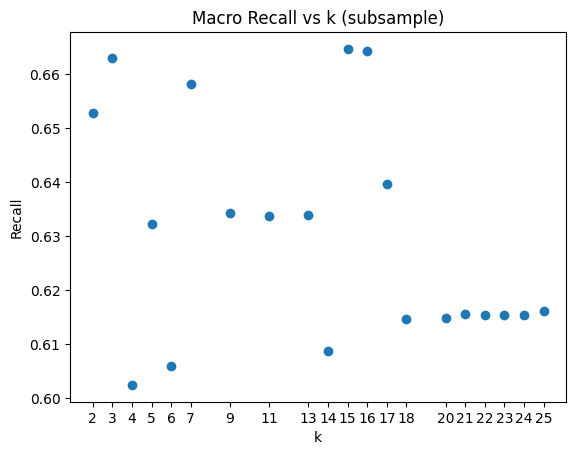

In [13]:
k_range = [2, 3, 4, 5, 6, 7, 9, 11, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24, 25]
scores = []

for k in k_range:
    model = make_pipeline(
        MinMaxScaler(),
        KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    )
    model.fit(X_train_s, y_train_s)
    pred = model.predict(X_test_s)
    recall = recall_score(y_test_s, pred, average='macro')
    scores.append(recall)
    print(f'k={k:>2} recall={recall:.4f}')

best_k = k_range[int(np.argmax(scores))]
print('\nBest k (recall):', best_k)

plt.figure()
plt.title('Macro Recall vs k (subsample)')
plt.xlabel('k')
plt.ylabel('Recall')
plt.scatter(k_range, scores)
plt.xticks(k_range)
plt.show()


#### F1-macro vs k

k= 2 f1=0.6674
k= 3 f1=0.6702
k= 4 f1=0.6036
k= 5 f1=0.6402
k= 6 f1=0.6042
k= 7 f1=0.6647
k= 9 f1=0.6445
k=11 f1=0.6437
k=13 f1=0.6402
k=14 f1=0.5988
k=15 f1=0.6703
k=16 f1=0.6706
k=17 f1=0.6407
k=18 f1=0.5995
k=20 f1=0.6016
k=21 f1=0.6019
k=22 f1=0.6019
k=23 f1=0.5952
k=24 f1=0.5952
k=25 f1=0.5933

Best k (F1-macro): 16


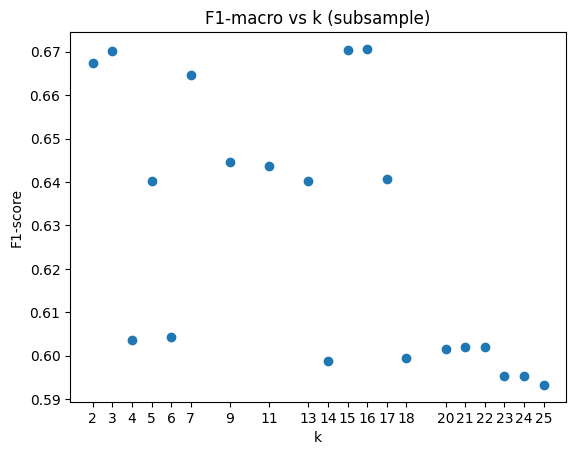

In [14]:
k_range = [2, 3, 4, 5, 6, 7, 9, 11, 13, 14, 15, 16, 17, 18, 20, 21, 22, 23, 24, 25]
scores = []

for k in k_range:
    model = make_pipeline(
        MinMaxScaler(),
        KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    )
    model.fit(X_train_s, y_train_s)
    pred = model.predict(X_test_s)
    f1 = f1_score(y_test_s, pred, average='macro')
    scores.append(f1)
    print(f'k={k:>2} f1={f1:.4f}')

best_k = k_range[int(np.argmax(scores))]
print('\nBest k (F1-macro):', best_k)

plt.figure()
plt.title('F1-macro vs k (subsample)')
plt.xlabel('k')
plt.ylabel('F1-score')
plt.scatter(k_range, scores)
plt.xticks(k_range)
plt.show()


### Final Model 1 (k = 3)

In [15]:
n_neighbors = 3

knn = KNeighborsClassifier(n_neighbors=n_neighbors, n_jobs=-1)
knn.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


## 6. Evaluation

### Train

In [16]:
pred_train = knn.predict(X_train_s)

print('Accuracy train:', accuracy_score(y_train_s, pred_train))
print(classification_report(y_train_s, pred_train))


Accuracy train: 0.9953
                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00     16206
                     Bot       0.84      0.88      0.86        24
                    DDoS       1.00      1.00      1.00      1593
             FTP-Patator       1.00      1.00      1.00        99
            Infiltration       1.00      1.00      1.00         1
                PortScan       0.98      0.99      0.98      1977
             SSH-Patator       1.00      0.99      0.99        73
Web Attack � Brute Force       0.89      0.84      0.86        19
        Web Attack � XSS       0.70      0.88      0.78         8

                accuracy                           1.00     20000
               macro avg       0.93      0.95      0.94     20000
            weighted avg       1.00      1.00      1.00     20000



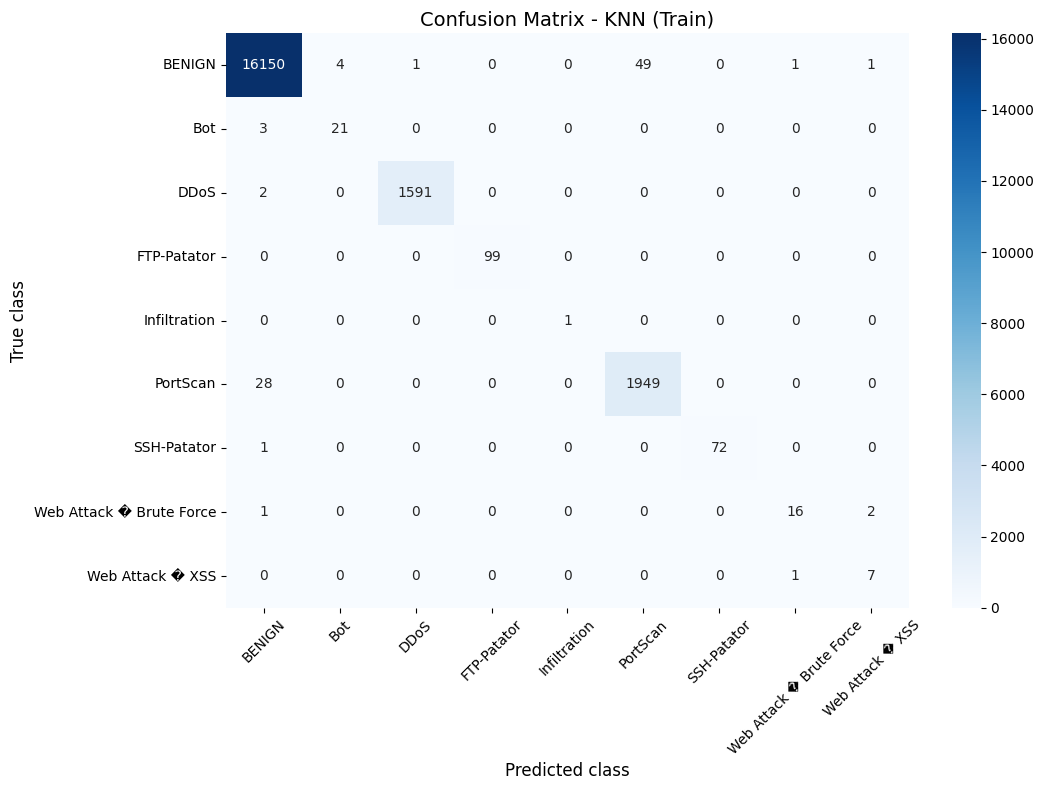

In [17]:
labels = sorted(y_train_s.unique())
cm = confusion_matrix(y_train_s, pred_train, labels=labels)

plt.figure(figsize=(11, 8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel('Predicted class', fontsize=12)
plt.ylabel('True class', fontsize=12)
plt.title('Confusion Matrix - KNN (Train)', fontsize=14)

plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


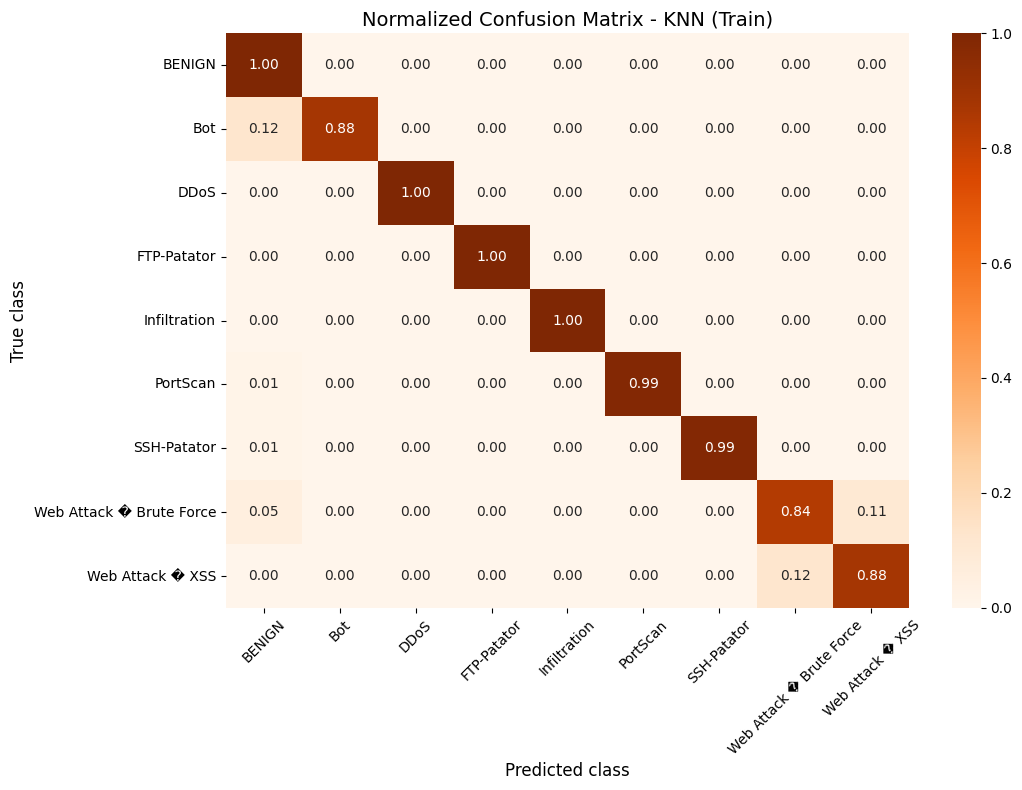

In [18]:
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(11, 8))
sns.heatmap(cm_norm,
            annot=True,
            fmt='.2f',
            cmap='Oranges',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel('Predicted class', fontsize=12)
plt.ylabel('True class', fontsize=12)
plt.title('Normalized Confusion Matrix - KNN (Train)', fontsize=14)

plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Test

In [19]:
pred_test = knn.predict(X_test_s)

print('Accuracy test:', accuracy_score(y_test_s, pred_test))
print(classification_report(y_test_s, pred_test))


KeyboardInterrupt: 

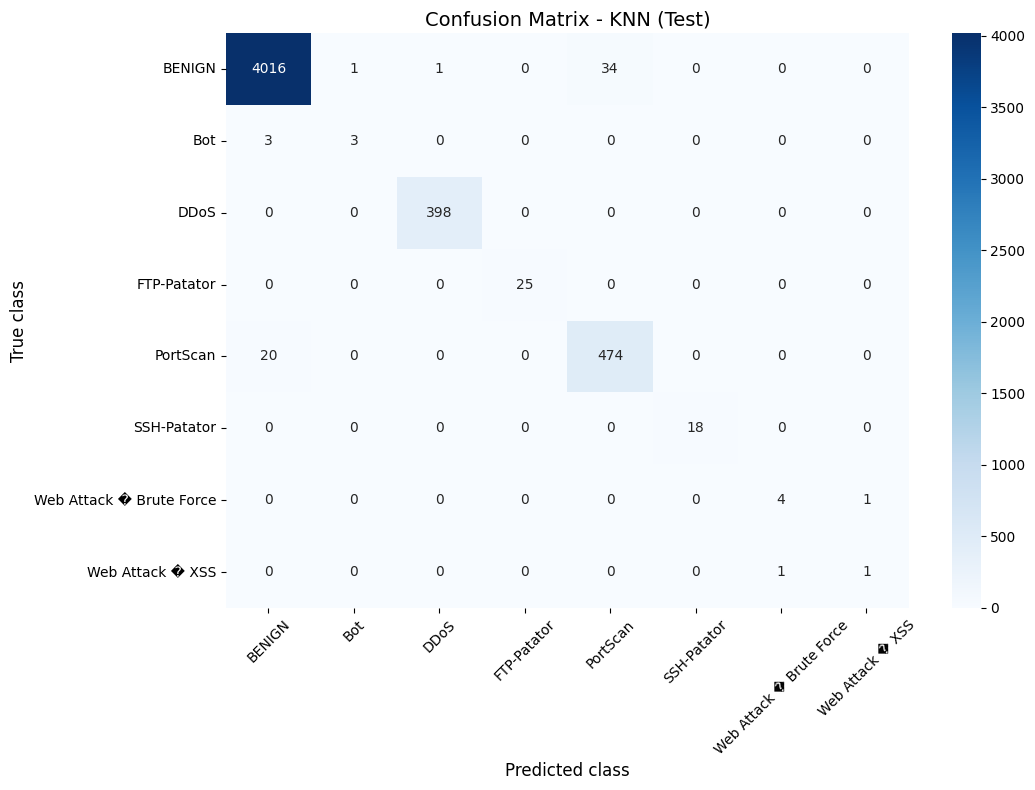

In [ ]:
labels = sorted(y_test_s.unique())
cm = confusion_matrix(y_test_s, pred_test, labels=labels)

plt.figure(figsize=(11, 8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel('Predicted class', fontsize=12)
plt.ylabel('True class', fontsize=12)
plt.title('Confusion Matrix - KNN (Test)', fontsize=14)

plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


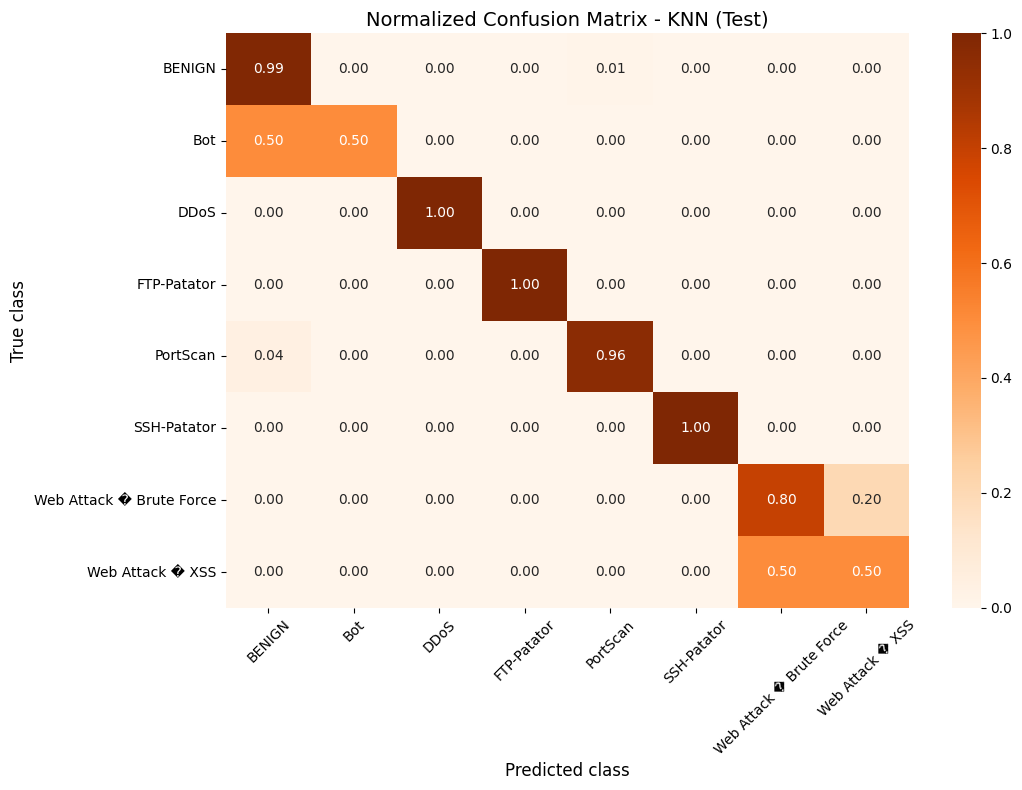

In [ ]:
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(11, 8))
sns.heatmap(cm_norm,
            annot=True,
            fmt='.2f',
            cmap='Oranges',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel('Predicted class', fontsize=12)
plt.ylabel('True class', fontsize=12)
plt.title('Normalized Confusion Matrix - KNN (Test)', fontsize=14)

plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


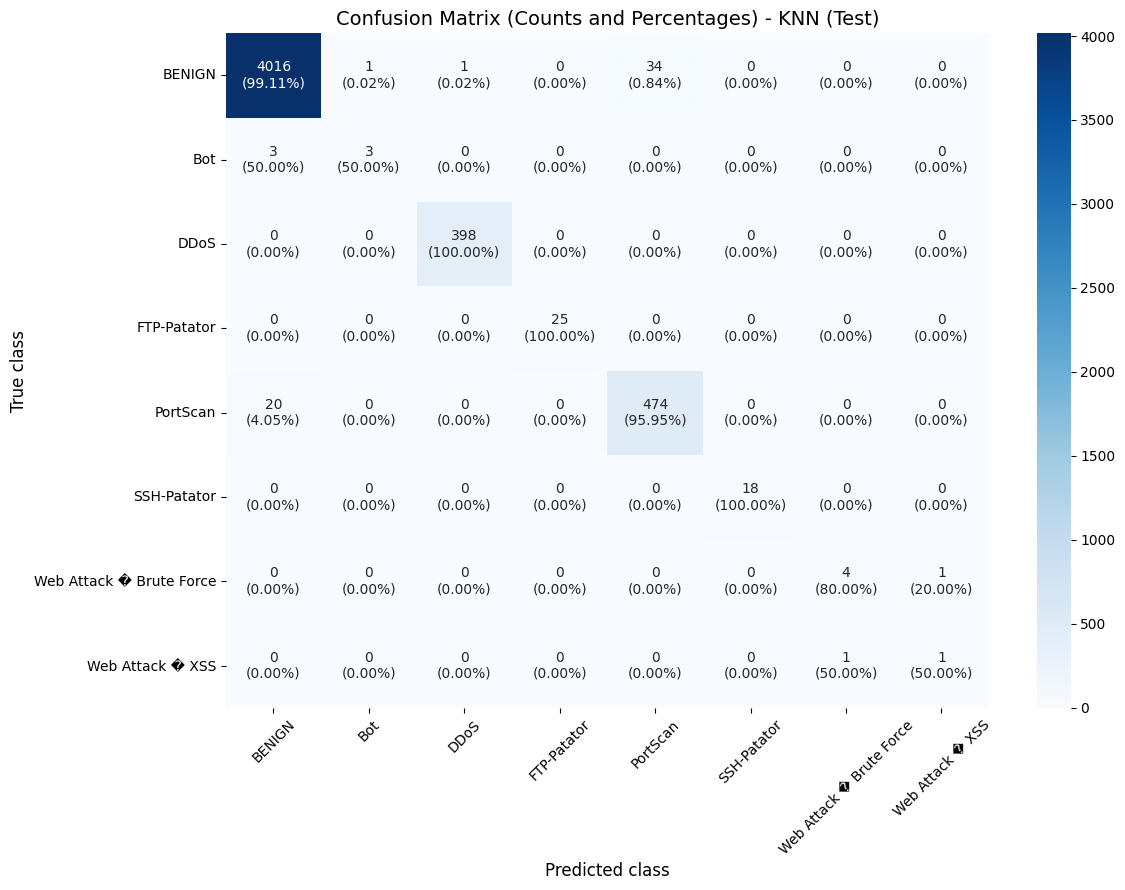

In [ ]:
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f'{cm[i, j]}\n({cm_norm[i, j]:.2%})'

plt.figure(figsize=(12, 9))
sns.heatmap(cm,
            annot=annot,
            fmt='',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel('Predicted class', fontsize=12)
plt.ylabel('True class', fontsize=12)
plt.title('Confusion Matrix (Counts and Percentages) - KNN (Test)', fontsize=14)

plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Final Model 2 (k = 15)

In [ ]:
n_neighbors = 15

knn = KNeighborsClassifier(n_neighbors=n_neighbors, n_jobs=-1)
knn.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",15
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


## 6. Evaluation

### Train

In [ ]:
pred_train = knn.predict(X_train_s)

print('Accuracy train:', accuracy_score(y_train_s, pred_train))
print(classification_report(y_train_s, pred_train))


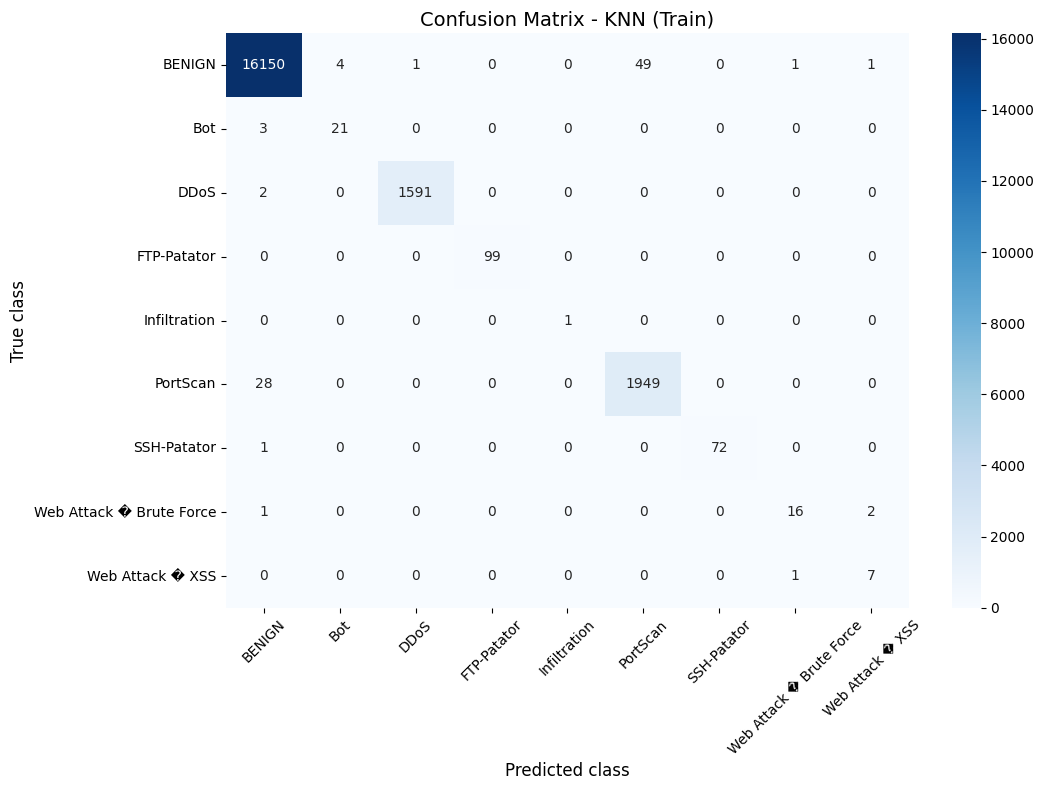

In [ ]:
labels = sorted(y_train_s.unique())
cm = confusion_matrix(y_train_s, pred_train, labels=labels)

plt.figure(figsize=(11, 8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel('Predicted class', fontsize=12)
plt.ylabel('True class', fontsize=12)
plt.title('Confusion Matrix - KNN (Train)', fontsize=14)

plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

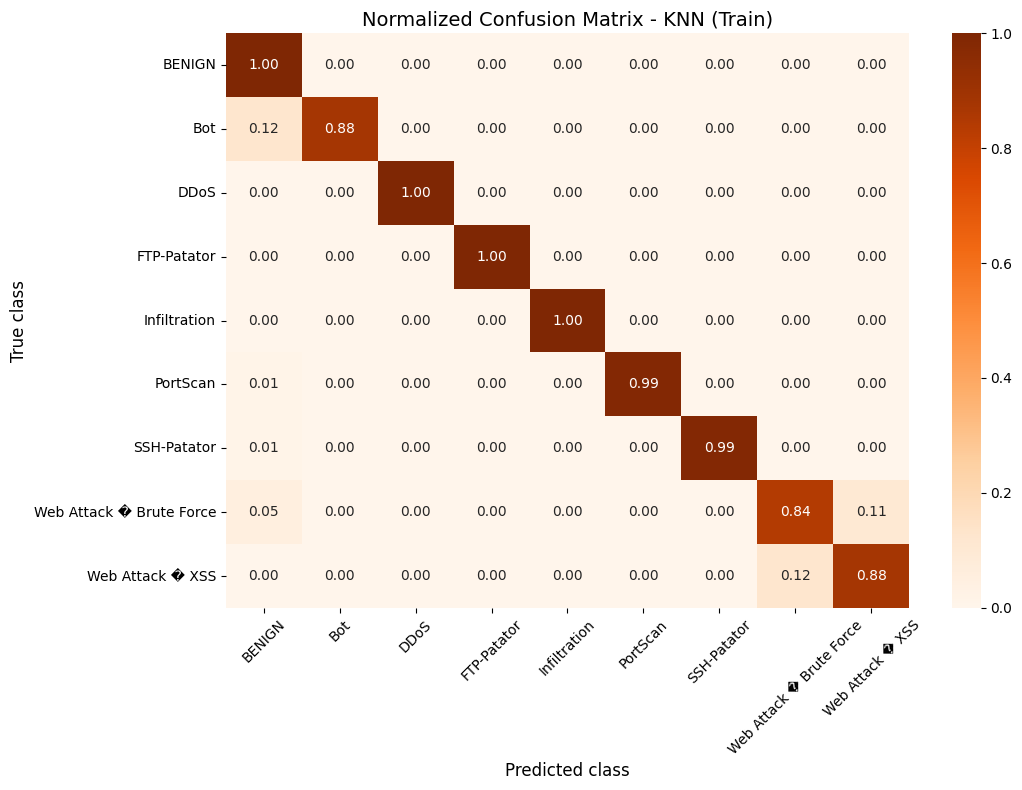

In [ ]:
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(11, 8))
sns.heatmap(cm_norm,
            annot=True,
            fmt='.2f',
            cmap='Oranges',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel('Predicted class', fontsize=12)
plt.ylabel('True class', fontsize=12)
plt.title('Normalized Confusion Matrix - KNN (Train)', fontsize=14)

plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Test


In [ ]:
pred_test = knn.predict(X_test_s)

print('Accuracy test:', accuracy_score(y_test_s, pred_test))
print(classification_report(y_test_s, pred_test))


Accuracy test: 0.9836
                          precision    recall  f1-score   support

                  BENIGN       0.99      0.99      0.99      4052
                     Bot       1.00      0.33      0.50         6
                    DDoS       1.00      1.00      1.00       398
             FTP-Patator       1.00      1.00      1.00        25
                PortScan       0.91      0.94      0.93       494
             SSH-Patator       1.00      1.00      1.00        18
Web Attack � Brute Force       0.71      1.00      0.83         5
        Web Attack � XSS       0.00      0.00      0.00         2

                accuracy                           0.98      5000
               macro avg       0.83      0.78      0.78      5000
            weighted avg       0.98      0.98      0.98      5000



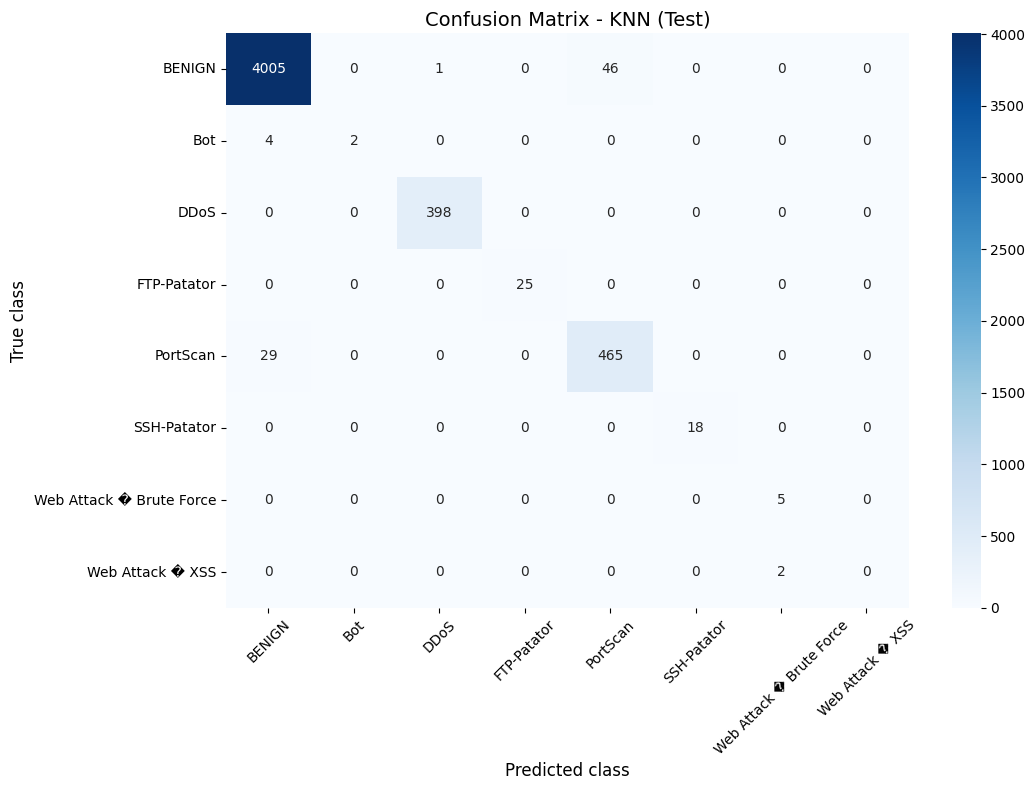

In [ ]:
labels = sorted(y_test_s.unique())
cm = confusion_matrix(y_test_s, pred_test, labels=labels)

plt.figure(figsize=(11, 8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel('Predicted class', fontsize=12)
plt.ylabel('True class', fontsize=12)
plt.title('Confusion Matrix - KNN (Test)', fontsize=14)

plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


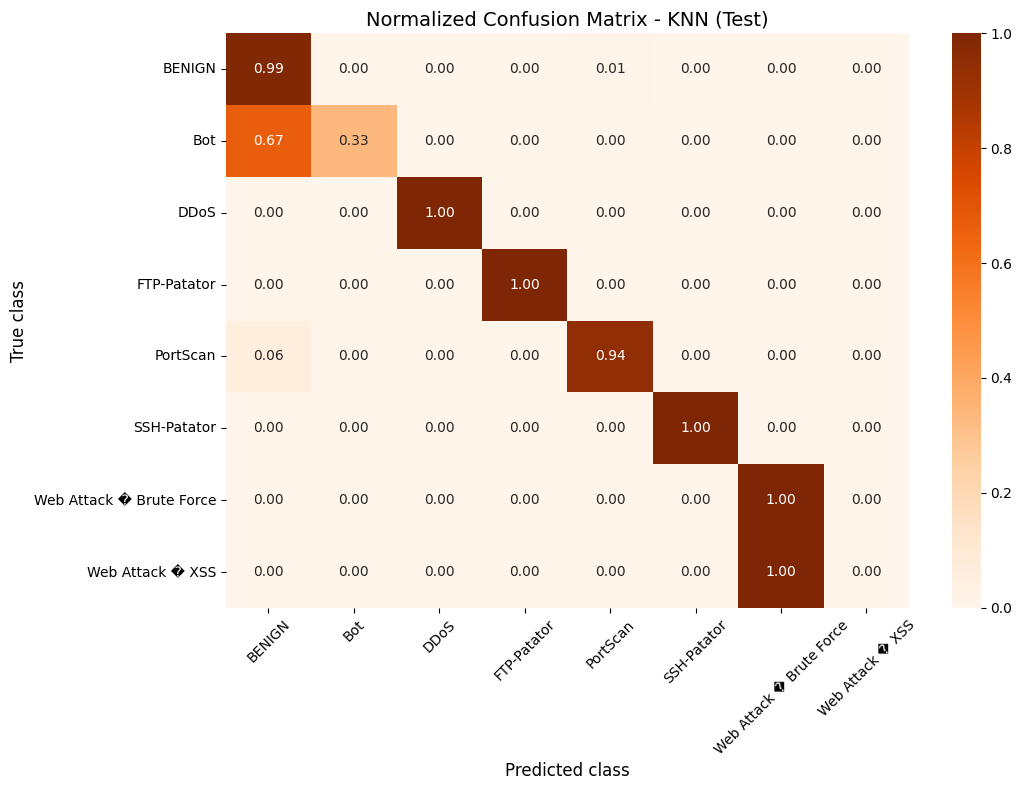

In [ ]:
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(11, 8))
sns.heatmap(cm_norm,
            annot=True,
            fmt='.2f',
            cmap='Oranges',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel('Predicted class', fontsize=12)
plt.ylabel('True class', fontsize=12)
plt.title('Normalized Confusion Matrix - KNN (Test)', fontsize=14)

plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



### IMPORTANCE

Calculando permutation importance...)
Tiempo: 47.4s

Top 20 variables más importantes:
                feature  importance      std
         PSH Flag Count     0.17732 0.003575
       Destination Port     0.04574 0.002539
 Init_Win_bytes_forward     0.03530 0.002701
         ACK Flag Count     0.02046 0.001598
          Fwd Packets/s     0.01488 0.001780
          Flow Duration     0.01484 0.001023
          Fwd IAT Total     0.01326 0.000980
      Packet Length Std     0.01094 0.001259
           Flow IAT Max     0.00860 0.001028
Init_Win_bytes_backward     0.00852 0.000776
            Fwd IAT Max     0.00794 0.001066
          Bwd IAT Total     0.00748 0.001327
  Bwd Packet Length Max     0.00570 0.001263
    Average Packet Size     0.00568 0.001032
          Bwd Packets/s     0.00496 0.000799
         Flow Packets/s     0.00418 0.001045
               Idle Max     0.00406 0.000858
     Packet Length Mean     0.00388 0.000760
            Fwd IAT Std     0.00370 0.000826
             

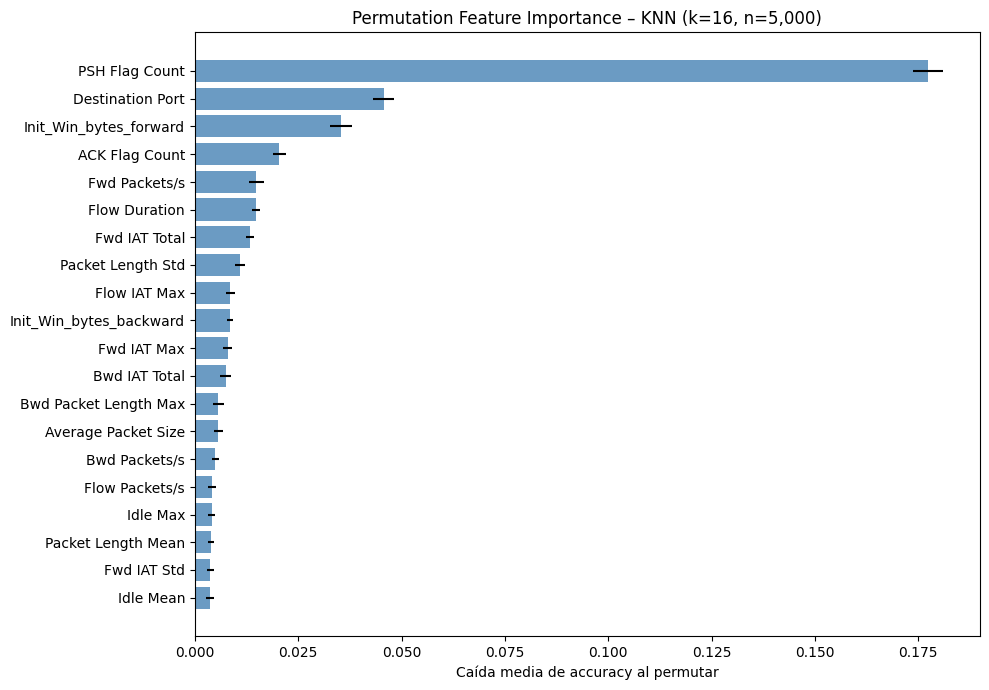

In [ ]:
# ── Permutation Feature Importance (KNN) ─────────────────────────────────────
from sklearn.inspection import permutation_importance
import time

# Muestra reducida estratificada para que sea manejable
SAMPLE_SIZE = 5_000
X_pi, _, y_pi, _ = train_test_split(
    X_norm, y,
    train_size=SAMPLE_SIZE,
    stratify=y,
    random_state=42
)

# Entrenamos un KNN con el mejor k sobre esa misma muestra
knn_pi = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn_pi.fit(X_pi, y_pi)

# Calculamos la importancia por permutación (n_repeats=10 es suficiente)
print("Calculando permutation importance...)")
t0 = time.time()
result = permutation_importance(
    knn_pi, X_pi, y_pi,
    scoring='accuracy',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
print(f"Tiempo: {time.time() - t0:.1f}s")

# Ordenamos por importancia media descendente
feat_imp = pd.DataFrame({
    'feature':    X_norm.columns,
    'importance': result.importances_mean,
    'std':        result.importances_std
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("\nTop 20 variables más importantes:")
print(feat_imp.head(20).to_string(index=False))

# Visualización: top 20
top20 = feat_imp.head(20)
plt.figure(figsize=(10, 7))
plt.barh(top20['feature'][::-1], top20['importance'][::-1],
         xerr=top20['std'][::-1], color='steelblue', alpha=0.8)
plt.xlabel('Caída media de accuracy al permutar')
plt.title(f'Permutation Feature Importance – KNN (k={best_k}, n={SAMPLE_SIZE:,})')
plt.tight_layout()
plt.show()